# Edinburgh Airbnb Price Prediction

## Section 06 — Machine Learning

This notebook builds price prediction models using the enriched Edinburgh
listings dataset created in Section 03.

## Objectives

- Frame the price prediction problem and evaluation metrics
- Engineer modelling features from enriched listing data
- Train and compare three model families
- Evaluate models using cross-validation
- Interpret the strongest drivers of listing price

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder


sns.set_theme(style="whitegrid")

project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent

processed_dir = (
    project_root
    / "data"
    / "processed"
    / "edinburgh"
    / "2026-06-23"
)
figures_dir = project_root / "reports" / "figures"
tables_dir = project_root / "reports" / "tables"
figures_dir.mkdir(parents=True, exist_ok=True)
tables_dir.mkdir(parents=True, exist_ok=True)

listings = pd.read_parquet(processed_dir / "listings_enriched.parquet")

model_data = listings[
    (listings["is_valid_price"] == True)
    & listings["price"].notna()
].copy()

print(f"Rows available for modelling: {len(model_data):,}")
model_data[["price", "room_type", "bedrooms", "review_scores_rating", "occupancy_proxy"]].head()

Rows available for modelling: 5,608


,price,room_type,bedrooms,review_scores_rating,occupancy_proxy
0,225.50,Entire home/apt,1.0,4.98,0.9233
1,202.00,Entire home/apt,2.0,4.66,0.5178
2,128.75,Entire home/apt,1.0,4.68,0.2932
3,220.00,Private room,1.0,4.88,0.7014
4,356.00,Entire home/apt,2.0,4.90,0.9233


## Problem framing

- **Target variable:** `price` (nightly listing price in GBP)
- **Problem type:** Supervised regression
- **Success metrics:** MAE, RMSE, and R²
- **Validation approach:** 5-fold cross-validation on the training set, plus hold-out test set

Lower MAE and RMSE are better. R² shows how much price variation the model explains.

In [2]:
feature_columns = [
    "room_type",
    "property_type",
    "bedrooms",
    "bathrooms",
    "beds",
    "accommodates",
    "review_scores_rating",
    "number_of_reviews",
    "availability_365",
    "occupancy_proxy",
    "host_tenure_years",
    "neighbourhood_median_price",
    "neighbourhood_listing_count",
    "neighbourhood_avg_rating",
]

X = model_data[feature_columns].copy()
y = model_data["price"].astype(float)

categorical_features = ["room_type", "property_type"]
numeric_features = [col for col in feature_columns if col not in categorical_features]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    (
                        "encoder",
                        OneHotEncoder(handle_unknown="ignore"),
                    ),
                ]
            ),
            categorical_features,
        ),
        (
            "numeric",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                ]
            ),
            numeric_features,
        ),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

print(f"Training rows: {len(X_train):,}")
print(f"Test rows: {len(X_test):,}")

Training rows: 4,486
Test rows: 1,122


## Model training and comparison

Three model families are tested:

1. **Ridge Regression** — linear baseline
2. **Random Forest** — non-linear tree ensemble
3. **Gradient Boosting** — boosted tree ensemble

In [3]:
models = {
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1,
    ),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
}

results = []
fitted_models = {}

for model_name, estimator in models.items():
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", estimator),
        ]
    )

    cv_mae = -cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=5,
        scoring="neg_mean_absolute_error",
        n_jobs=-1,
    )

    pipeline.fit(X_train, y_train)
    predictions = pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    results.append(
        {
            "model": model_name,
            "cv_mae_mean": round(cv_mae.mean(), 2),
            "test_mae": round(mae, 2),
            "test_rmse": round(rmse, 2),
            "test_r2": round(r2, 4),
        }
    )

    fitted_models[model_name] = pipeline

results_df = pd.DataFrame(results).sort_values("test_mae")
results_df

,model,cv_mae_mean,test_mae,test_rmse,test_r2
2,Gradient Boosting,93.23,93.84,330.99,0.0848
0,Ridge Regression,94.31,94.04,320.05,0.1442
1,Random Forest,94.83,96.82,332.54,0.0761


### Business interpretation

The model comparison shows how well listing attributes can explain nightly price.
If tree-based models outperform the linear model, price relationships in Edinburgh
are likely non-linear and interaction-driven. The best model can support automated
pricing guidance, but prediction error should still be communicated to stakeholders
because Airbnb pricing also depends on seasonality and events not fully captured here.

## Residual analysis for the best model

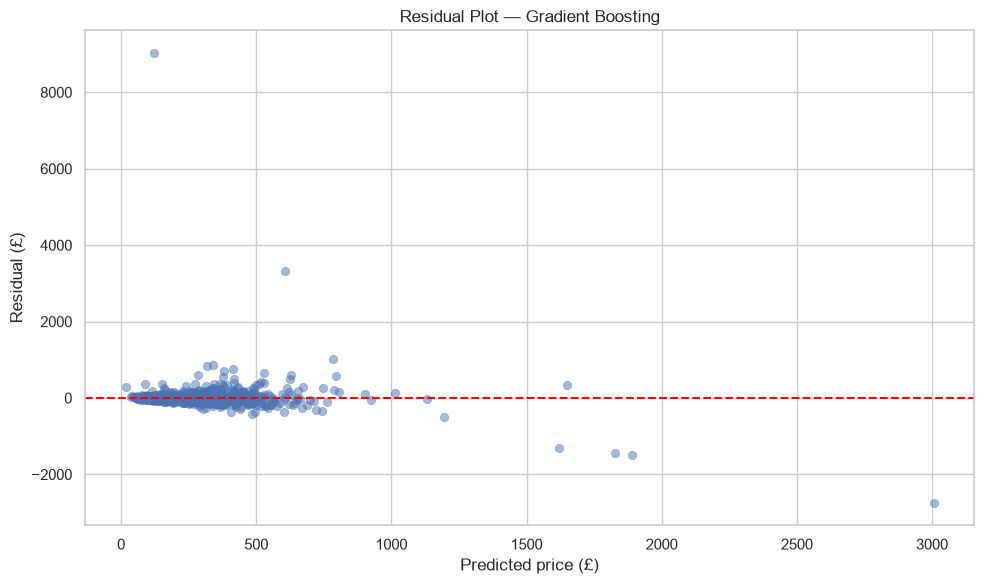

Best model: Gradient Boosting


In [4]:
best_model_name = results_df.iloc[0]["model"]
best_model = fitted_models[best_model_name]
best_predictions = best_model.predict(X_test)
residuals = y_test - best_predictions

plt.figure(figsize=(10, 6))
sns.scatterplot(x=best_predictions, y=residuals, alpha=0.5, edgecolor=None)
plt.axhline(0, color="red", linestyle="--")
plt.title(f"Residual Plot — {best_model_name}")
plt.xlabel("Predicted price (£)")
plt.ylabel("Residual (£)")
plt.tight_layout()
plt.savefig(figures_dir / "08_price_model_residuals.png", dpi=150)
plt.show()

print(f"Best model: {best_model_name}")

### Business interpretation

Residuals show where the model systematically under- or over-predicts price.
Wide residual spread at higher price points may indicate luxury or unusual properties
that need separate pricing logic. Operational teams should treat extreme residuals as
candidates for manual review rather than automatic price recommendations.

## Feature importance (Random Forest)

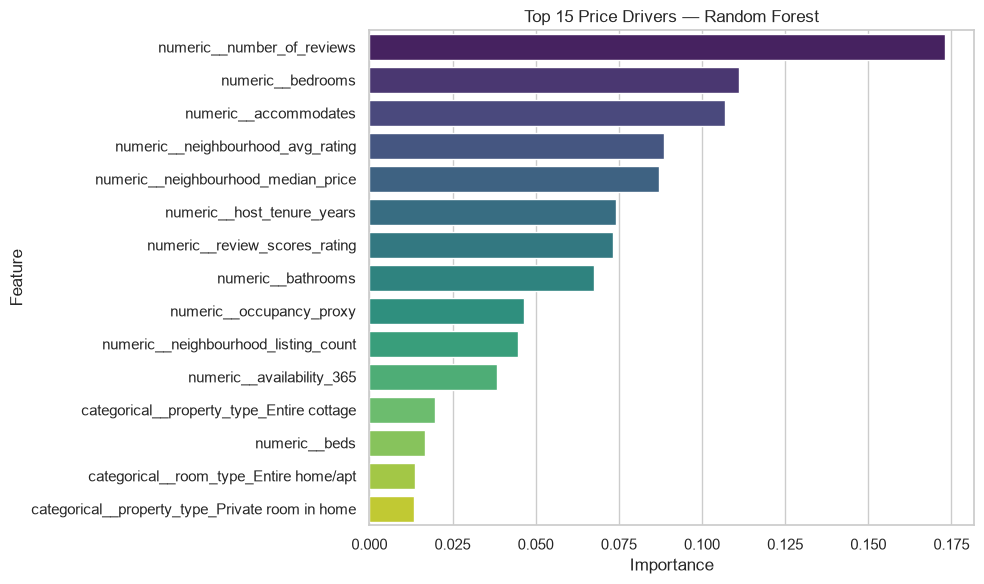

,feature,importance
62,numeric__number_of_reviews,0.173112
57,numeric__bedrooms,0.111177
60,numeric__accommodates,0.106830
68,numeric__neighbourhood_avg_rating,0.088568
66,numeric__neighbourhood_median_price,0.087145
65,numeric__host_tenure_years,0.074208
61,numeric__review_scores_rating,0.073105
58,numeric__bathrooms,0.067611
64,numeric__occupancy_proxy,0.046355
67,numeric__neighbourhood_listing_count,0.044536


In [5]:
rf_pipeline = fitted_models["Random Forest"]
rf_model = rf_pipeline.named_steps["model"]
rf_preprocessor = rf_pipeline.named_steps["preprocessor"]

feature_names = rf_preprocessor.get_feature_names_out()
importance = pd.DataFrame(
    {
        "feature": feature_names,
        "importance": rf_model.feature_importances_,
    }
).sort_values("importance", ascending=False)

top_features = importance.head(15)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_features,
    x="importance",
    y="feature",
    hue="feature",
    palette="viridis",
    legend=False,
)
plt.title("Top 15 Price Drivers — Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(figures_dir / "09_price_model_feature_importance.png", dpi=150)
plt.show()

top_features

### Business interpretation

Feature importance highlights the listing attributes with the strongest association
with price. Location proxies, room configuration, and review performance are often
among the most influential drivers. Hosts and revenue managers should focus on these
variables first when estimating a competitive nightly rate.

In [6]:
results_output = tables_dir / "price_model_comparison.csv"
importance_output = tables_dir / "price_model_feature_importance.csv"

results_df.to_csv(results_output, index=False)
importance.to_csv(importance_output, index=False)

print(f"Saved: {results_output}")
print(f"Saved: {importance_output}")

Saved: d:\Airbnb-Market-Intelligence\airbnb-market-intelligence-edinburgh\reports\tables\price_model_comparison.csv
Saved: d:\Airbnb-Market-Intelligence\airbnb-market-intelligence-edinburgh\reports\tables\price_model_feature_importance.csv


## Section 06 Summary

This notebook completed the core machine learning requirements:

- Framed the price prediction problem
- Engineered features from enriched listing data
- Trained Ridge, Random Forest, and Gradient Boosting models
- Evaluated models with cross-validation and hold-out testing
- Analysed residuals and feature importance

Outputs were saved to `reports/tables/` and `reports/figures/` for the final report.